In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import torch
from prism.config import PROCESSED_DATA_DIR, MODELS_DIR
from prism.legacy import normalise
from prism.load_models import load_mlp
from prism.pr_save_test import save_partial_responses_results, test_refactored_partial_responses, load_partial_responses, compare_and_visualize
from prism.partial_responses import partial_responses, PartialResponseCalculator
from prism.lasso import lasso
from prism.nomogram import nomogram

2024-08-19 09:29:59.355 | INFO     | prism.config:<module>:11 - PROJ_ROOT path is: C:\Users\localuser\PRiSM\prism_github


In [3]:
def print_first_responses(x_train, x_test, rows=5, columns=5, n_univariate=11):
    print(f"First few univariate responses (train):\n{x_train[:rows, :columns]}")
    print(f"First few bivariate responses (train):\n{x_train[:rows, n_univariate:(n_univariate+columns)]}")
    print(f"First few univariate responses (test):\n{x_test[:rows, :columns]}")
    print(f"First few bivariate responses (test):\n{x_test[:rows, n_univariate:(n_univariate+columns)]}")

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def find_large_deviations(torch_tensor, numpy_array, threshold=0.1):
    diff = np.abs(torch_tensor.numpy() - numpy_array)
    large_dev_indices = np.argwhere(diff > threshold)
    return large_dev_indices

def visualize_large_deviations(torch_tensor, numpy_array, large_dev_indices, num_samples=5):
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    for i, (row, col) in enumerate(large_dev_indices[:num_samples]):
        window_size = 5
        row_start, row_end = max(0, row-window_size), min(torch_tensor.shape[0], row+window_size+1)
        col_start, col_end = max(0, col-window_size), min(torch_tensor.shape[1], col+window_size+1)
        
        torch_subset = torch_tensor[row_start:row_end, col_start:col_end].numpy()
        numpy_subset = numpy_array[row_start:row_end, col_start:col_end]
        diff_subset = np.abs(torch_subset - numpy_subset)
        
        vmin = min(torch_subset.min(), numpy_subset.min())
        vmax = max(torch_subset.max(), numpy_subset.max())
        
        axes[i, 0].imshow(torch_subset, cmap='coolwarm', vmin=vmin, vmax=vmax)
        axes[i, 0].set_title(f'PyTorch (Row: {row}, Col: {col})')
        axes[i, 1].imshow(numpy_subset, cmap='coolwarm', vmin=vmin, vmax=vmax)
        axes[i, 1].set_title(f'NumPy (Row: {row}, Col: {col})')
        im = axes[i, 2].imshow(diff_subset, cmap='viridis')
        axes[i, 2].set_title('Absolute Difference')
        plt.colorbar(im, ax=axes[i, 2])
        
    plt.tight_layout()
    plt.show()

def scatter_plot_large_deviations(large_dev_indices, shape):
    plt.figure(figsize=(12, 8))
    plt.scatter(large_dev_indices[:, 0], large_dev_indices[:, 1], alpha=0.5)
    plt.xlabel('Row Index')
    plt.ylabel('Column Index')
    plt.title('Distribution of Large Deviations')
    plt.xlim(0, shape[0])
    plt.ylim(0, shape[1])
    plt.gca().invert_yaxis()  # Invert y-axis to match matrix coordinates
    plt.colorbar(label='Density')
    plt.show()

def compare_and_visualize(torch_tensor, numpy_array):
    print("Data Types:")
    print(f"PyTorch Tensor: {torch_tensor.dtype}")
    print(f"NumPy Array: {numpy_array.dtype}")
    print()

    print("Shape:")
    print(f"PyTorch Tensor: {torch_tensor.shape}")
    print(f"NumPy Array: {numpy_array.shape}")
    print()

    print("Basic Statistics:")
    print("Mean:")
    print(f"PyTorch Tensor: {torch_tensor.mean().item()}")
    print(f"NumPy Array: {numpy_array.mean()}")
    print()

    print("Standard Deviation:")
    print(f"PyTorch Tensor: {torch_tensor.std().item()}")
    print(f"NumPy Array: {numpy_array.std()}")
    print()

    print("Min:")
    print(f"PyTorch Tensor: {torch_tensor.min().item()}")
    print(f"NumPy Array: {numpy_array.min()}")
    print()

    print("Max:")
    print(f"PyTorch Tensor: {torch_tensor.max().item()}")
    print(f"NumPy Array: {numpy_array.max()}")
    print()

    # Overall distribution plot
    plt.figure(figsize=(12, 6))
    sns.histplot(torch_tensor.numpy().flatten(), kde=True, color='blue', alpha=0.5, label='PyTorch')
    sns.histplot(numpy_array.flatten(), kde=True, color='red', alpha=0.5, label='NumPy')
    plt.title('Distribution of Values')
    plt.legend()
    plt.show()

    # Correlation plot
    plt.figure(figsize=(10, 8))
    plt.scatter(torch_tensor.numpy().flatten(), numpy_array.flatten(), alpha=0.1)
    plt.xlabel('PyTorch Tensor Values')
    plt.ylabel('NumPy Array Values')
    plt.title('Correlation between PyTorch Tensor and NumPy Array')
    plt.plot([numpy_array.min(), numpy_array.max()], [numpy_array.min(), numpy_array.max()], 'r--', lw=2)
    plt.show()

    # Find and visualize large deviations
    large_dev_indices = find_large_deviations(torch_tensor, numpy_array)
    visualize_large_deviations(torch_tensor, numpy_array, large_dev_indices)

    # Scatter plot of large deviation indices
    scatter_plot_large_deviations(large_dev_indices, torch_tensor.shape)

    # Print summary of large deviations
    print(f"Number of elements with large deviations: {len(large_dev_indices)}")
    print(f"Percentage of elements with large deviations: {len(large_dev_indices) / torch_tensor.numel() * 100:.2f}%")

# Load and setup

In [5]:
%reload_ext autoreload

In [6]:
seed = 257
np.random.seed(seed)
torch.manual_seed(seed)

In [7]:
import matplotlib.pyplot as plt

def plot_histograms(pr_train_benchmark, x_train, num_subplot_cols=3):
    # Univariate responses only
    m = x_train.shape[1]

    # Calculate number of rows needed for the subplots
    num_subplot_rows = (m + num_subplot_cols - 1) // num_subplot_cols

    # Create a figure with subplots arranged in 3 columns
    fig, axes = plt.subplots(num_subplot_rows, num_subplot_cols, figsize=(12, 4 * num_subplot_rows))
    fig.suptitle(f'Histograms of Benchmark Training Partial Responses')

    # Plot histogram for each column
    for i in range(m):
        row = i // num_subplot_cols
        col = i % num_subplot_cols
        ax = axes[row, col] if num_subplot_rows > 1 else axes[col]
        ax.hist(pr_train_benchmark[:, i], bins=15, edgecolor='black')
        ax.set_title(x_train.columns[i])
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')

    # Remove any unused subplots
    for i in range(m, num_subplot_rows * num_subplot_cols):
        row = i // num_subplot_cols
        col = i % num_subplot_cols
        fig.delaxes(axes[row, col] if num_subplot_rows > 1 else axes[col])

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

## Load and preprocess data

In [8]:
data_train = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_train.csv'))
data_test = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_test.csv'))
data_val = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_val.csv'))

data_train_test = pd.concat([data_train,data_test]) # used for axis annotation in some plotting functions

# drop id column
data_train.drop('trr_id_code',axis=1,inplace=True)
data_test.drop('trr_id_code',axis=1,inplace=True)
data_val.drop('trr_id_code',axis=1,inplace=True)

target_col = 'oneyearmort'

x_train0 = data_train.drop(target_col,axis=1)
y_train = data_train[target_col]

x_test0 = data_test.drop(target_col,axis=1)
y_test = data_test[target_col]

x_val0 = data_val.drop(target_col,axis=1)
y_val = data_val[target_col]

[x_train,x_test] = normalise(x_train0,x_test0)
x_val = normalise(x_val0)

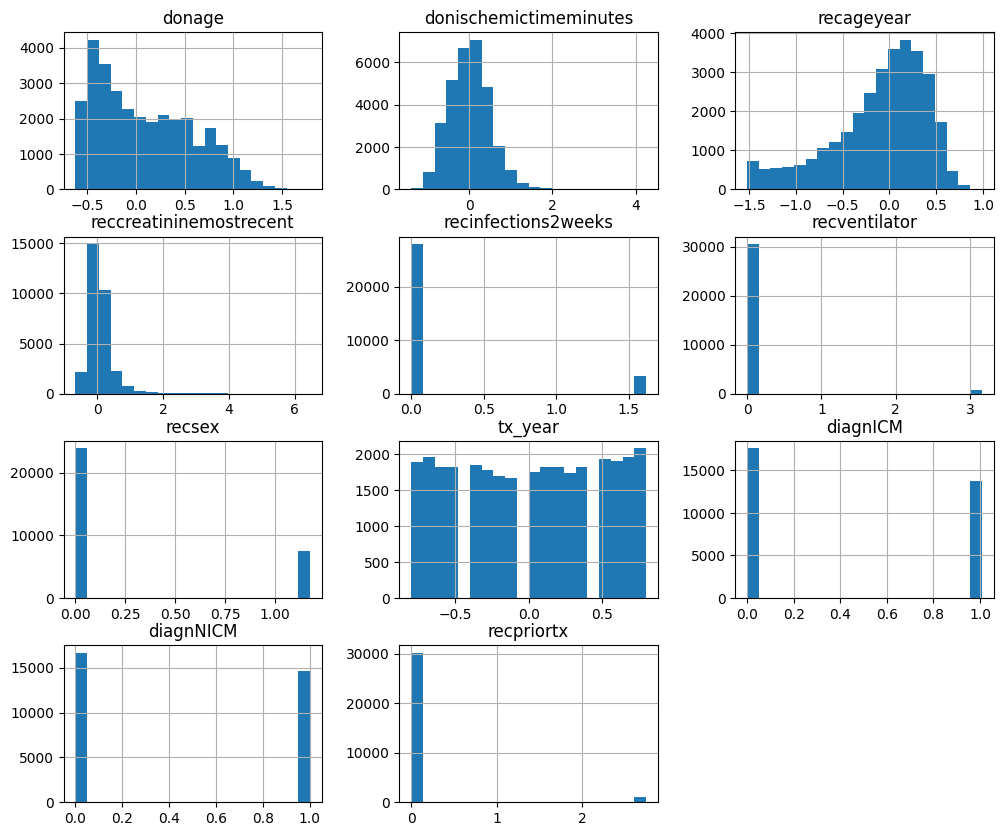

In [9]:
x_train.hist(bins=20,figsize=(12,10));

In [10]:
feature_names = [
    'don age',
    'don isch time min',
    'rec age yr',
    'rec creat',
    'rec infect 2wk',
    'rec vent',
    'rec sex',
    'tx year',
    'ICM',
    'NICM',
    'prior tx'
]

## Load MLP

In [11]:
filename_mlp = 'mlp_model_20240705_135534'
try:
    mlp, mlp_params, mlp_metrics = load_mlp(filename_mlp, MODELS_DIR)
    print("Model loaded successfully")
    print("Derived Model Structure:")
    print("\nModel Parameters:")
    print(mlp_params)
    print("\nModel Metrics:")
    print(mlp_metrics)
except Exception as e:
    print(f"Error loading model: {e}")
    raise

# Extract method and device from mlp_params, with defaults
method = mlp_params.get('method', 'dirac')
device = mlp_params.get('device', 'cpu')

Model loaded successfully
Derived Model Structure:

Model Parameters:
{'n_hidden': 10, 'weight_decay': 1e-05, 'lr': 0.001, 'patience': 50, 'tolerance': 0.0001, 'batch_size': 1024, 'device': 'cpu', 'seed': 257}

Model Metrics:
{'prevalence': 0.123, 'sensitivity': 0.241, 'specificity': 0.864, 'accuracy': 0.797, 'ppv': 0.175, 'auc score': 0.601, 'auc lower ci': '0.577', 'auc upper ci': '0.626'}


## Load benchmark partial responses

In [12]:
pr_load = load_partial_responses()
pr_train_benchmark = pr_load['partial_responses_train']
pr_test_benchmark = pr_load['partial_responses_test']

Data successfully loaded from C:\Users\localuser\PRiSM\prism_github\models\partial_responses_data.pkl
Loaded data contains the following keys: x_train, x_test, model, partial_responses_train, partial_responses_test, method, device
x_train shape: (31315, 11)
x_test shape: (6120, 11)
partial_responses_train shape: (31315, 66)
partial_responses_test shape: (6120, 66)


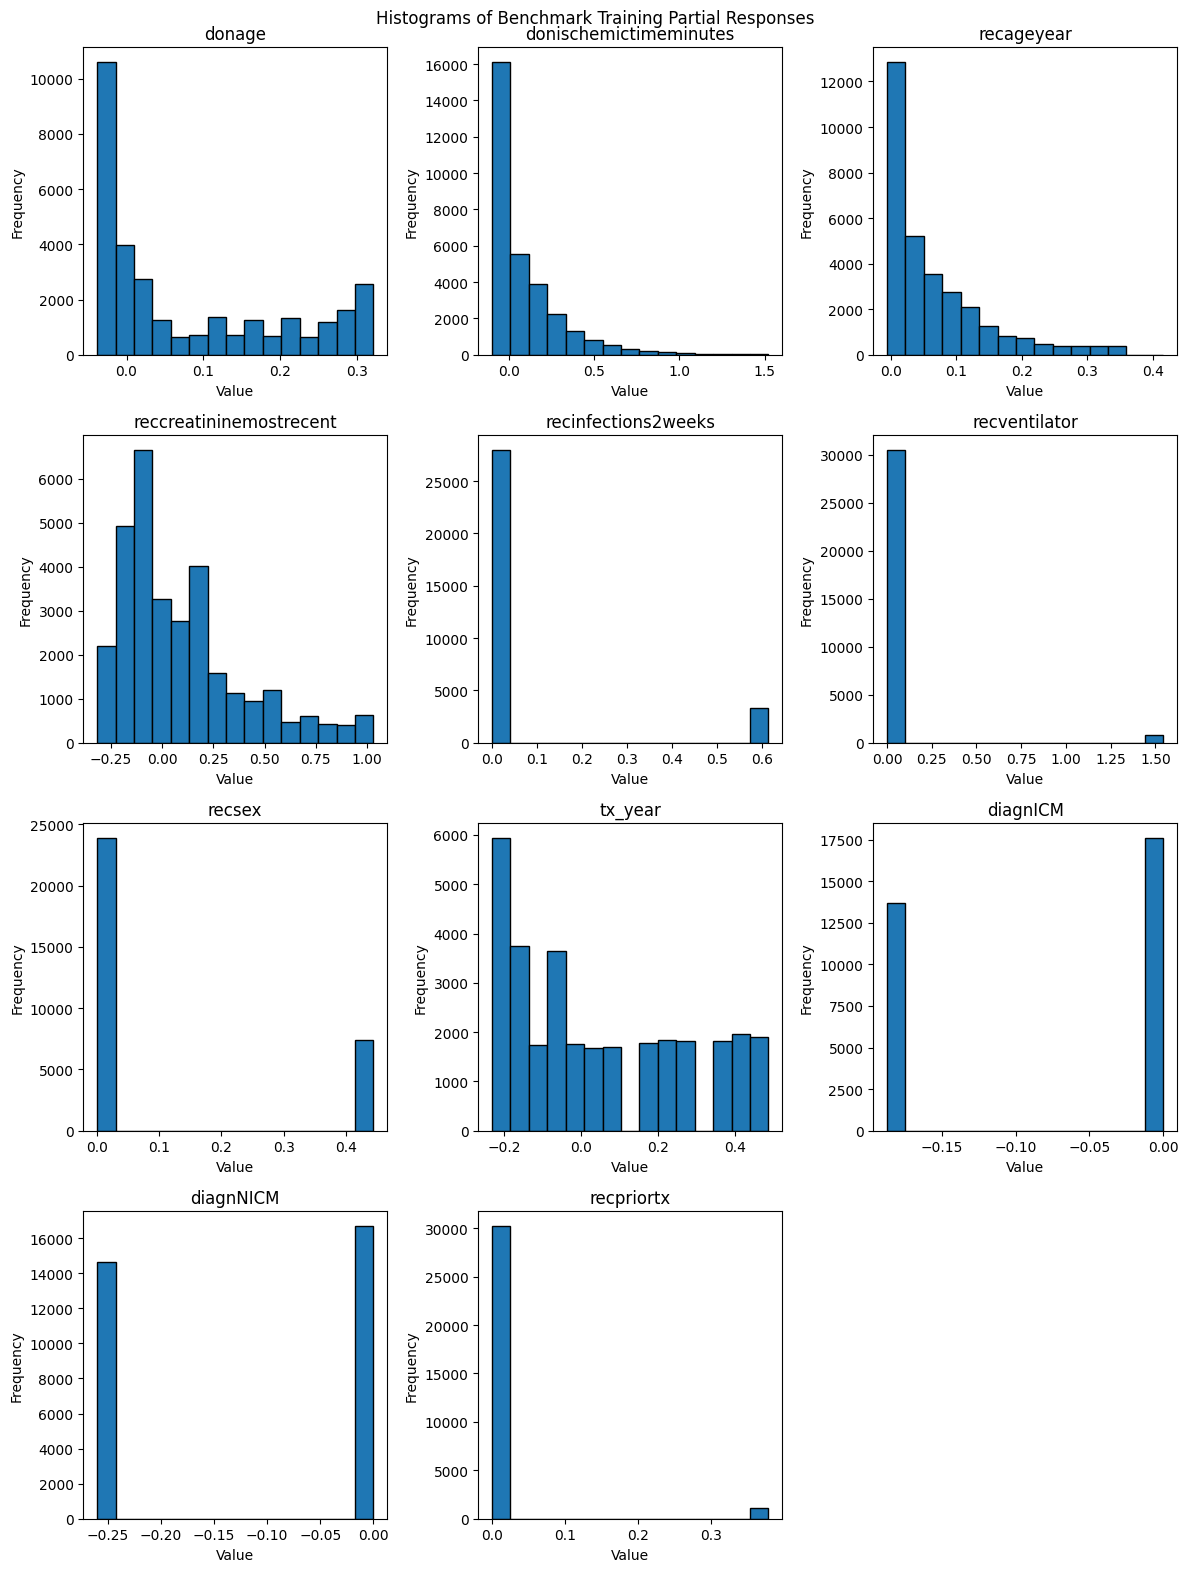

In [13]:
plot_histograms(pr_train_benchmark,x_train)

# Test Dirac

In [14]:
x_train_tensor = torch.tensor(x_train.values, dtype=torch.float32, device=device)
x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32,device=device)

In [15]:
pr = PartialResponseCalculator(mlp, method, device, input_dim=x_train_tensor.shape[1])

In [16]:
univariate_train, bivariate_train, bivariate_inputs = pr.calculate(x_train_tensor)

In [17]:
pr_train, pr_test, bivariate_inputs = partial_responses(x_train_tensor,x_test_tensor,mlp,method='dirac',device=device)

In [18]:
print_first_responses(pr_train,pr_test)

First few univariate responses (train):
tensor([[ 0.0716, -0.0867, -0.0057,  0.2100,  0.0000],
        [-0.0269,  0.1127, -0.0032, -0.1168,  0.0000],
        [ 0.2512, -0.0407,  0.0694,  0.0664,  0.0000],
        [ 0.2083,  0.6771,  0.0565,  0.4328,  0.0000],
        [-0.0382, -0.0836,  0.0169, -0.2702,  0.0000]])
First few bivariate responses (train):
tensor([[ 0.0065, -0.0075, -0.0054,  0.0000,  0.0000],
        [ 0.0166,  0.0041, -0.0159,  0.0000,  0.0000],
        [-0.0001,  0.0402, -0.0058,  0.0000,  0.0000],
        [-0.0387,  0.0310, -0.0015,  0.0000,  0.0000],
        [-0.0411, -0.0092, -0.0393,  0.0000,  0.0000]])
First few univariate responses (test):
tensor([[-0.0102,  0.1832,  0.0044,  0.0664,  0.0000],
        [-0.0382,  0.0829,  0.2849,  0.1513,  0.0000],
        [-0.0326,  0.2240,  0.0342,  0.0000,  0.0000],
        [-0.0269, -0.0407,  0.1513, -0.0435,  0.0000],
        [ 0.3009,  0.1306,  0.1152,  0.5716,  0.0000]])
First few bivariate responses (test):
tensor([[ 0.0281

In [19]:
print_first_responses(pr_train_benchmark, pr_test_benchmark)

First few univariate responses (train):
[[ 0.07161093 -0.08673906 -0.00569773  0.20996237  0.        ]
 [-0.02694654  0.11274576 -0.00319147 -0.11675644  0.        ]
 [ 0.25121975 -0.04073429  0.06940937  0.06640053  0.        ]
 [ 0.20826769  0.67714942  0.05648136  0.43277049  0.        ]
 [-0.03824949 -0.08359814  0.01686096 -0.27024698  0.        ]]
First few bivariate responses (train):
[[ 0.00654554 -0.00751519 -0.00542164  0.          0.        ]
 [ 0.01660681  0.00406265 -0.01590681  0.          0.        ]
 [-0.00010848  0.04021502 -0.00579095  0.          0.        ]
 [-0.03867877  0.03100348 -0.00154138  0.          0.        ]
 [-0.04112434 -0.00924683 -0.03928757  0.          0.        ]]
First few univariate responses (test):
[[-0.01015663  0.1832056   0.0043993   0.06640053  0.        ]
 [-0.03822756  0.08289409  0.28486729  0.15125036  0.        ]
 [-0.03259659  0.22404289  0.03423142  0.          0.        ]
 [-0.02694654 -0.04073429  0.15129423 -0.04352379  0.        

## compare dirac results

In [20]:
## test dirac
test_refactored_partial_responses(partial_responses,tensor_input=True)

Refactored function produces different results from the original implementation. atol = 1e-07, rtol = 1e-05
Differences found in partial_responses_train
Max absolute difference: 1.430511474609375e-06
Max relative difference: 0.00010408634670246127
Differences found in partial_responses_test
Max absolute difference: 1.430511474609375e-06
Max relative difference: 9.475296008247299e-05


False

# Test Lebesgue CPU 500

In [21]:
# Load results from old method
pr_load_leb= load_partial_responses(MODELS_DIR.joinpath("partial_responses_data_leb500.pkl"))
pr_train_benchmark_leb = pr_load_leb['partial_responses_train']
pr_test_benchmark_leb = pr_load_leb['partial_responses_test']

Data successfully loaded from C:\Users\localuser\PRiSM\prism_github\models\partial_responses_data_leb500.pkl
Loaded data contains the following keys: x_train, x_test, model, partial_responses_train, partial_responses_test, method, device
x_train shape: (500, 11)
x_test shape: (500, 11)
partial_responses_train shape: (500, 66)
partial_responses_test shape: (500, 66)


In [22]:
print_first_responses(pr_train_benchmark_leb, pr_test_benchmark_leb)

First few univariate responses (train):
[[ 0.02279246 -0.13538277 -0.08238709  0.05137408 -0.04876649]
 [-0.18926609  0.06411755 -0.04966962 -0.16132271 -0.04876649]
 [ 0.24780893 -0.07403123  0.07245362 -0.04652226 -0.04876649]
 [ 0.1899035   0.45994484  0.0572989   0.2237339  -0.04876649]
 [-0.1667074  -0.20167506  0.00046611 -0.25231373 -0.04876649]]
First few bivariate responses (train):
[[ 0.00975614 -0.0014504  -0.00784853  0.0015941  -0.00162662]
 [ 0.00449143 -0.00350396 -0.01813054 -0.00167009 -0.00617562]
 [ 0.00969791  0.01454909 -0.00556087  0.0005069   0.00979852]
 [-0.05770344  0.01386476 -0.0322869   0.00121743  0.00653278]
 [-0.0161572  -0.00503564 -0.03246517 -0.00096593 -0.00687471]]
First few univariate responses (test):
[[-0.53211224 -0.39187014 -0.45838583 -0.41380584 -0.44975626]
 [-0.54525983 -0.43861377 -0.47356451 -0.33227766 -0.44975626]
 [-0.54459131 -0.37141097 -0.40668476 -0.47929466 -0.44975626]
 [-0.54169858 -0.48624599 -0.27472937 -0.52340114 -0.44975626

In [23]:
# View new lebesgue results
%reload_ext autoreload

pr_train_leb, pr_test_leb, bivariate_inputs_leb = partial_responses(x_train_tensor[:500,:],x_test_tensor[:500,:],mlp,method='lebesgue',device='cpu')

Unvariate 0 on cpu
Unvariate 1 on cpu
Unvariate 2 on cpu
Unvariate 3 on cpu
Unvariate 4 on cpu
Unvariate 5 on cpu
Unvariate 6 on cpu
Unvariate 7 on cpu
Unvariate 8 on cpu
Unvariate 9 on cpu
Unvariate 10 on cpu
Bivariate 0,1 on cpu
Bivariate 0,2 on cpu
Bivariate 0,3 on cpu
Bivariate 0,4 on cpu
Bivariate 0,5 on cpu
Bivariate 0,6 on cpu
Bivariate 0,7 on cpu
Bivariate 0,8 on cpu
Bivariate 0,9 on cpu
Bivariate 0,10 on cpu
Bivariate 1,2 on cpu
Bivariate 1,3 on cpu
Bivariate 1,4 on cpu
Bivariate 1,5 on cpu
Bivariate 1,6 on cpu
Bivariate 1,7 on cpu
Bivariate 1,8 on cpu
Bivariate 1,9 on cpu
Bivariate 1,10 on cpu
Bivariate 2,3 on cpu
Bivariate 2,4 on cpu
Bivariate 2,5 on cpu
Bivariate 2,6 on cpu
Bivariate 2,7 on cpu
Bivariate 2,8 on cpu
Bivariate 2,9 on cpu
Bivariate 2,10 on cpu
Bivariate 3,4 on cpu
Bivariate 3,5 on cpu
Bivariate 3,6 on cpu
Bivariate 3,7 on cpu
Bivariate 3,8 on cpu
Bivariate 3,9 on cpu
Bivariate 3,10 on cpu
Bivariate 4,5 on cpu
Bivariate 4,6 on cpu
Bivariate 4,7 on cpu
Bivariate

In [24]:
print_first_responses(pr_train_leb, pr_test_leb)

First few univariate responses (train):
tensor([[ 0.0228, -0.1354, -0.0824,  0.0514, -0.0488],
        [-0.1893,  0.0641, -0.0497, -0.1613, -0.0488],
        [ 0.2478, -0.0740,  0.0725, -0.0465, -0.0488],
        [ 0.1899,  0.4599,  0.0573,  0.2237, -0.0488],
        [-0.1667, -0.2017,  0.0005, -0.2523, -0.0488]])
First few bivariate responses (train):
tensor([[ 0.0098, -0.0015, -0.0078,  0.0016, -0.0016],
        [ 0.0045, -0.0035, -0.0181, -0.0017, -0.0062],
        [ 0.0097,  0.0145, -0.0056,  0.0005,  0.0098],
        [-0.0577,  0.0139, -0.0323,  0.0012,  0.0065],
        [-0.0162, -0.0050, -0.0325, -0.0010, -0.0069]])
First few univariate responses (test):
tensor([[-0.5321, -0.3919, -0.4584, -0.4138, -0.4498],
        [-0.5453, -0.4386, -0.4736, -0.3323, -0.4498],
        [-0.5446, -0.3714, -0.4067, -0.4793, -0.4498],
        [-0.5417, -0.4862, -0.2747, -0.5234, -0.4498],
        [-0.1191, -0.4170, -0.3111,  0.0644, -0.4498]])
First few bivariate responses (test):
tensor([[0.4250,

In [25]:
# Test lebesgue
%reload_ext autoreload
test_refactored_partial_responses(partial_responses,filename=MODELS_DIR.joinpath("partial_responses_data_leb500.pkl"), tensor_input=True)

Unvariate 0 on cpu
Unvariate 1 on cpu
Unvariate 2 on cpu
Unvariate 3 on cpu
Unvariate 4 on cpu
Unvariate 5 on cpu
Unvariate 6 on cpu
Unvariate 7 on cpu
Unvariate 8 on cpu
Unvariate 9 on cpu
Unvariate 10 on cpu
Bivariate 0,1 on cpu
Bivariate 0,2 on cpu
Bivariate 0,3 on cpu
Bivariate 0,4 on cpu
Bivariate 0,5 on cpu
Bivariate 0,6 on cpu
Bivariate 0,7 on cpu
Bivariate 0,8 on cpu
Bivariate 0,9 on cpu
Bivariate 0,10 on cpu
Bivariate 1,2 on cpu
Bivariate 1,3 on cpu
Bivariate 1,4 on cpu
Bivariate 1,5 on cpu
Bivariate 1,6 on cpu
Bivariate 1,7 on cpu
Bivariate 1,8 on cpu
Bivariate 1,9 on cpu
Bivariate 1,10 on cpu
Bivariate 2,3 on cpu
Bivariate 2,4 on cpu
Bivariate 2,5 on cpu
Bivariate 2,6 on cpu
Bivariate 2,7 on cpu
Bivariate 2,8 on cpu
Bivariate 2,9 on cpu
Bivariate 2,10 on cpu
Bivariate 3,4 on cpu
Bivariate 3,5 on cpu
Bivariate 3,6 on cpu
Bivariate 3,7 on cpu
Bivariate 3,8 on cpu
Bivariate 3,9 on cpu
Bivariate 3,10 on cpu
Bivariate 4,5 on cpu
Bivariate 4,6 on cpu
Bivariate 4,7 on cpu
Bivariate

False

# Test lebesgue CPU 2000

In [26]:
import psutil
import os

def get_system_resources():
    # CPU information
    cpu_count = os.cpu_count()
    cpu_usage = psutil.cpu_percent(interval=1)

    # Memory information
    mem = psutil.virtual_memory()
    available_memory = mem.available / (1024 * 1024)  # Convert to MB

    print(f"CPU Cores: {cpu_count}")
    print(f"CPU Usage: {cpu_usage}%")
    print(f"Available Memory: {available_memory:.2f} MB")

    return {
        "cpu_count": cpu_count,
        "cpu_usage": cpu_usage,
        "available_memory": available_memory,
    }

resources = get_system_resources()

CPU Cores: 16
CPU Usage: 17.8%
Available Memory: 19109.23 MB


In [27]:
# Load results from old method
pr_load_leb= load_partial_responses(MODELS_DIR.joinpath("pr_cpu_lebesgue_20240816_170150.pkl"))
pr_train_benchmark_leb_2k = pr_load_leb['partial_responses_train']
pr_test_benchmark_leb_2k = pr_load_leb['partial_responses_test']


Data successfully loaded from C:\Users\localuser\PRiSM\prism_github\models\pr_cpu_lebesgue_20240816_170150.pkl
Loaded data contains the following keys: x_train, x_test, model, partial_responses_train, partial_responses_test, method, device
x_train shape: (2000, 11)
x_test shape: (2000, 11)
partial_responses_train shape: (2000, 66)
partial_responses_test shape: (2000, 66)


In [61]:
%reload_ext autoreload

device = 'cpu'

x_train_tensor = torch.tensor(x_train.values, dtype=torch.float32, device=device)
x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32,device=device)

pr_train_leb_2k, pr_test_leb_2k, bivariate_inputs_leb_2k = partial_responses(x_train_tensor[:2000,:],x_test_tensor[:2000,:],mlp,method='lebesgue',device=device,batch_size=2000);

Unvariate 0 on cpu
Unvariate 1 on cpu
Unvariate 2 on cpu
Unvariate 3 on cpu
Unvariate 4 on cpu
Unvariate 5 on cpu
Unvariate 6 on cpu
Unvariate 7 on cpu
Unvariate 8 on cpu
Unvariate 9 on cpu
Unvariate 10 on cpu
Bivariate 0,1 on cpu
Bivariate 0,2 on cpu
Bivariate 0,3 on cpu
Bivariate 0,4 on cpu
Bivariate 0,5 on cpu
Bivariate 0,6 on cpu
Bivariate 0,7 on cpu
Bivariate 0,8 on cpu
Bivariate 0,9 on cpu
Bivariate 0,10 on cpu
Bivariate 1,2 on cpu
Bivariate 1,3 on cpu
Bivariate 1,4 on cpu
Bivariate 1,5 on cpu
Bivariate 1,6 on cpu
Bivariate 1,7 on cpu
Bivariate 1,8 on cpu
Bivariate 1,9 on cpu
Bivariate 1,10 on cpu
Bivariate 2,3 on cpu
Bivariate 2,4 on cpu
Bivariate 2,5 on cpu
Bivariate 2,6 on cpu
Bivariate 2,7 on cpu
Bivariate 2,8 on cpu
Bivariate 2,9 on cpu
Bivariate 2,10 on cpu
Bivariate 3,4 on cpu
Bivariate 3,5 on cpu
Bivariate 3,6 on cpu
Bivariate 3,7 on cpu
Bivariate 3,8 on cpu
Bivariate 3,9 on cpu
Bivariate 3,10 on cpu
Bivariate 4,5 on cpu
Bivariate 4,6 on cpu
Bivariate 4,7 on cpu
Bivariate

In [54]:
print_first_responses(pr_train_leb_2k, pr_test_leb_2k)

First few univariate responses (train):
tensor([[ 0.0222, -0.1418, -0.0857,  0.0479, -0.0491],
        [-0.1942,  0.0582, -0.0524, -0.1643, -0.0491],
        [ 0.2531, -0.0804,  0.0711, -0.0500, -0.0491],
        [ 0.1936,  0.4541,  0.0558,  0.2210, -0.0491],
        [-0.1713, -0.2078, -0.0015, -0.2539, -0.0491]])
First few bivariate responses (train):
tensor([[ 0.0112, -0.0013, -0.0087,  0.0028, -0.0017],
        [ 0.0059, -0.0020, -0.0196, -0.0005, -0.0055],
        [ 0.0115,  0.0144, -0.0073,  0.0020,  0.0064],
        [-0.0576,  0.0138, -0.0346,  0.0026,  0.0041],
        [-0.0169, -0.0038, -0.0341,  0.0002, -0.0059]])
First few univariate responses (test):
tensor([[-0.5348, -0.3825, -0.4539, -0.4105, -0.4554],
        [-0.5456, -0.4310, -0.4668, -0.3284, -0.4554],
        [-0.5463, -0.3614, -0.4024, -0.4767, -0.4554],
        [-0.5437, -0.4819, -0.2711, -0.5213, -0.4554],
        [-0.1089, -0.4085, -0.3072,  0.0701, -0.4554]])
First few bivariate responses (test):
tensor([[0.4245,

In [55]:
print_first_responses(pr_train_benchmark_leb_2k, pr_test_benchmark_leb_2k)

First few univariate responses (train):
[[ 0.02220881 -0.14181936 -0.08567131  0.04791009 -0.04912555]
 [-0.1941973   0.05821919 -0.05236351 -0.16433847 -0.04912555]
 [ 0.25309598 -0.08035314  0.07109129 -0.05002487 -0.04912555]
 [ 0.19358945  0.45411789  0.05583167  0.2210207  -0.04912555]
 [-0.17131197 -0.20779407 -0.00153708 -0.25388396 -0.04912555]]
First few bivariate responses (train):
[[ 0.01123413 -0.00134256 -0.00868134  0.00279103 -0.00174187]
 [ 0.0058635  -0.0020462  -0.01963957 -0.00053424 -0.00549492]
 [ 0.01152132  0.01435027 -0.00729018  0.00199009  0.00635386]
 [-0.0576371   0.01377874 -0.03455305  0.00261738  0.00406238]
 [-0.0169408  -0.00379623 -0.03409243  0.00015123 -0.00586825]]
First few univariate responses (test):
[[-0.53482759 -0.38247073 -0.45387995 -0.41054976 -0.45540726]
 [-0.54564226 -0.43100011 -0.46683419 -0.32836759 -0.45540726]
 [-0.54626524 -0.36140859 -0.40236485 -0.47668135 -0.45540726]
 [-0.54374659 -0.48192441 -0.27110088 -0.52128971 -0.45540726

Data Types:
PyTorch Tensor: torch.float32
NumPy Array: float64

Shape:
PyTorch Tensor: torch.Size([2000, 66])
NumPy Array: (2000, 66)

Basic Statistics:
Mean:
PyTorch Tensor: 0.00013781434972770512
NumPy Array: 0.00013783417153042746

Standard Deviation:
PyTorch Tensor: 0.07101757824420929
NumPy Array: 0.07101731439211904

Min:
PyTorch Tensor: -0.6779278516769409
NumPy Array: -0.6779278516769409

Max:
PyTorch Tensor: 1.1969616413116455
NumPy Array: 1.1969616413116455



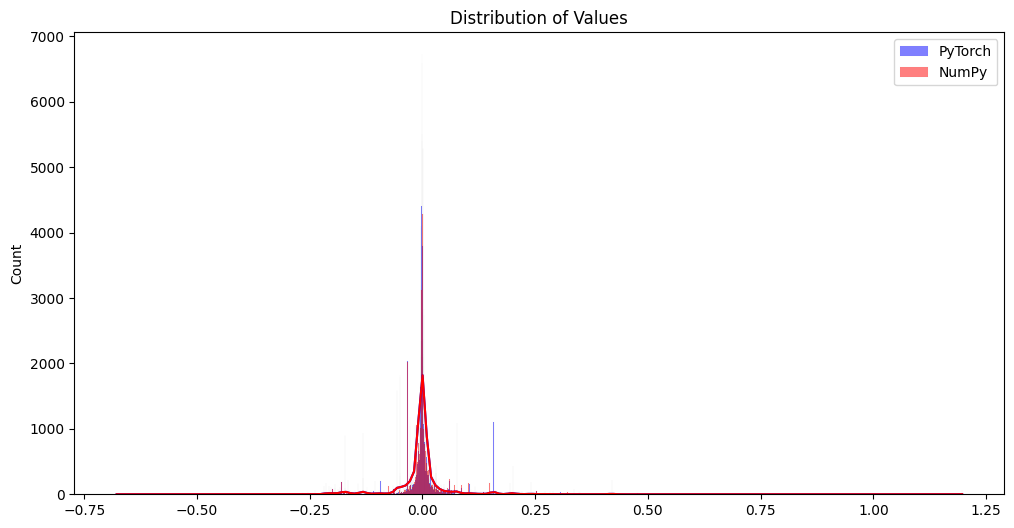

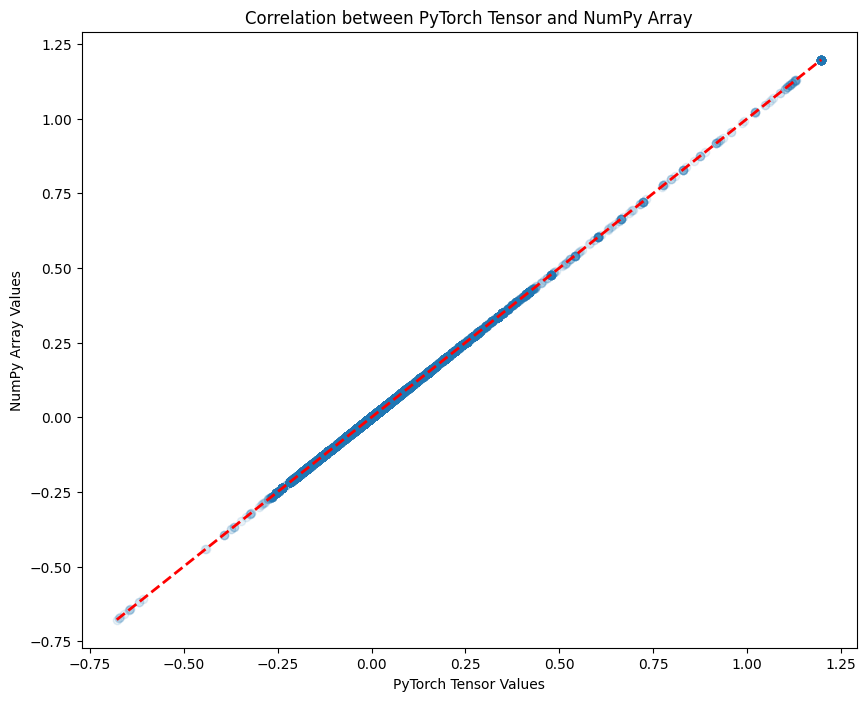

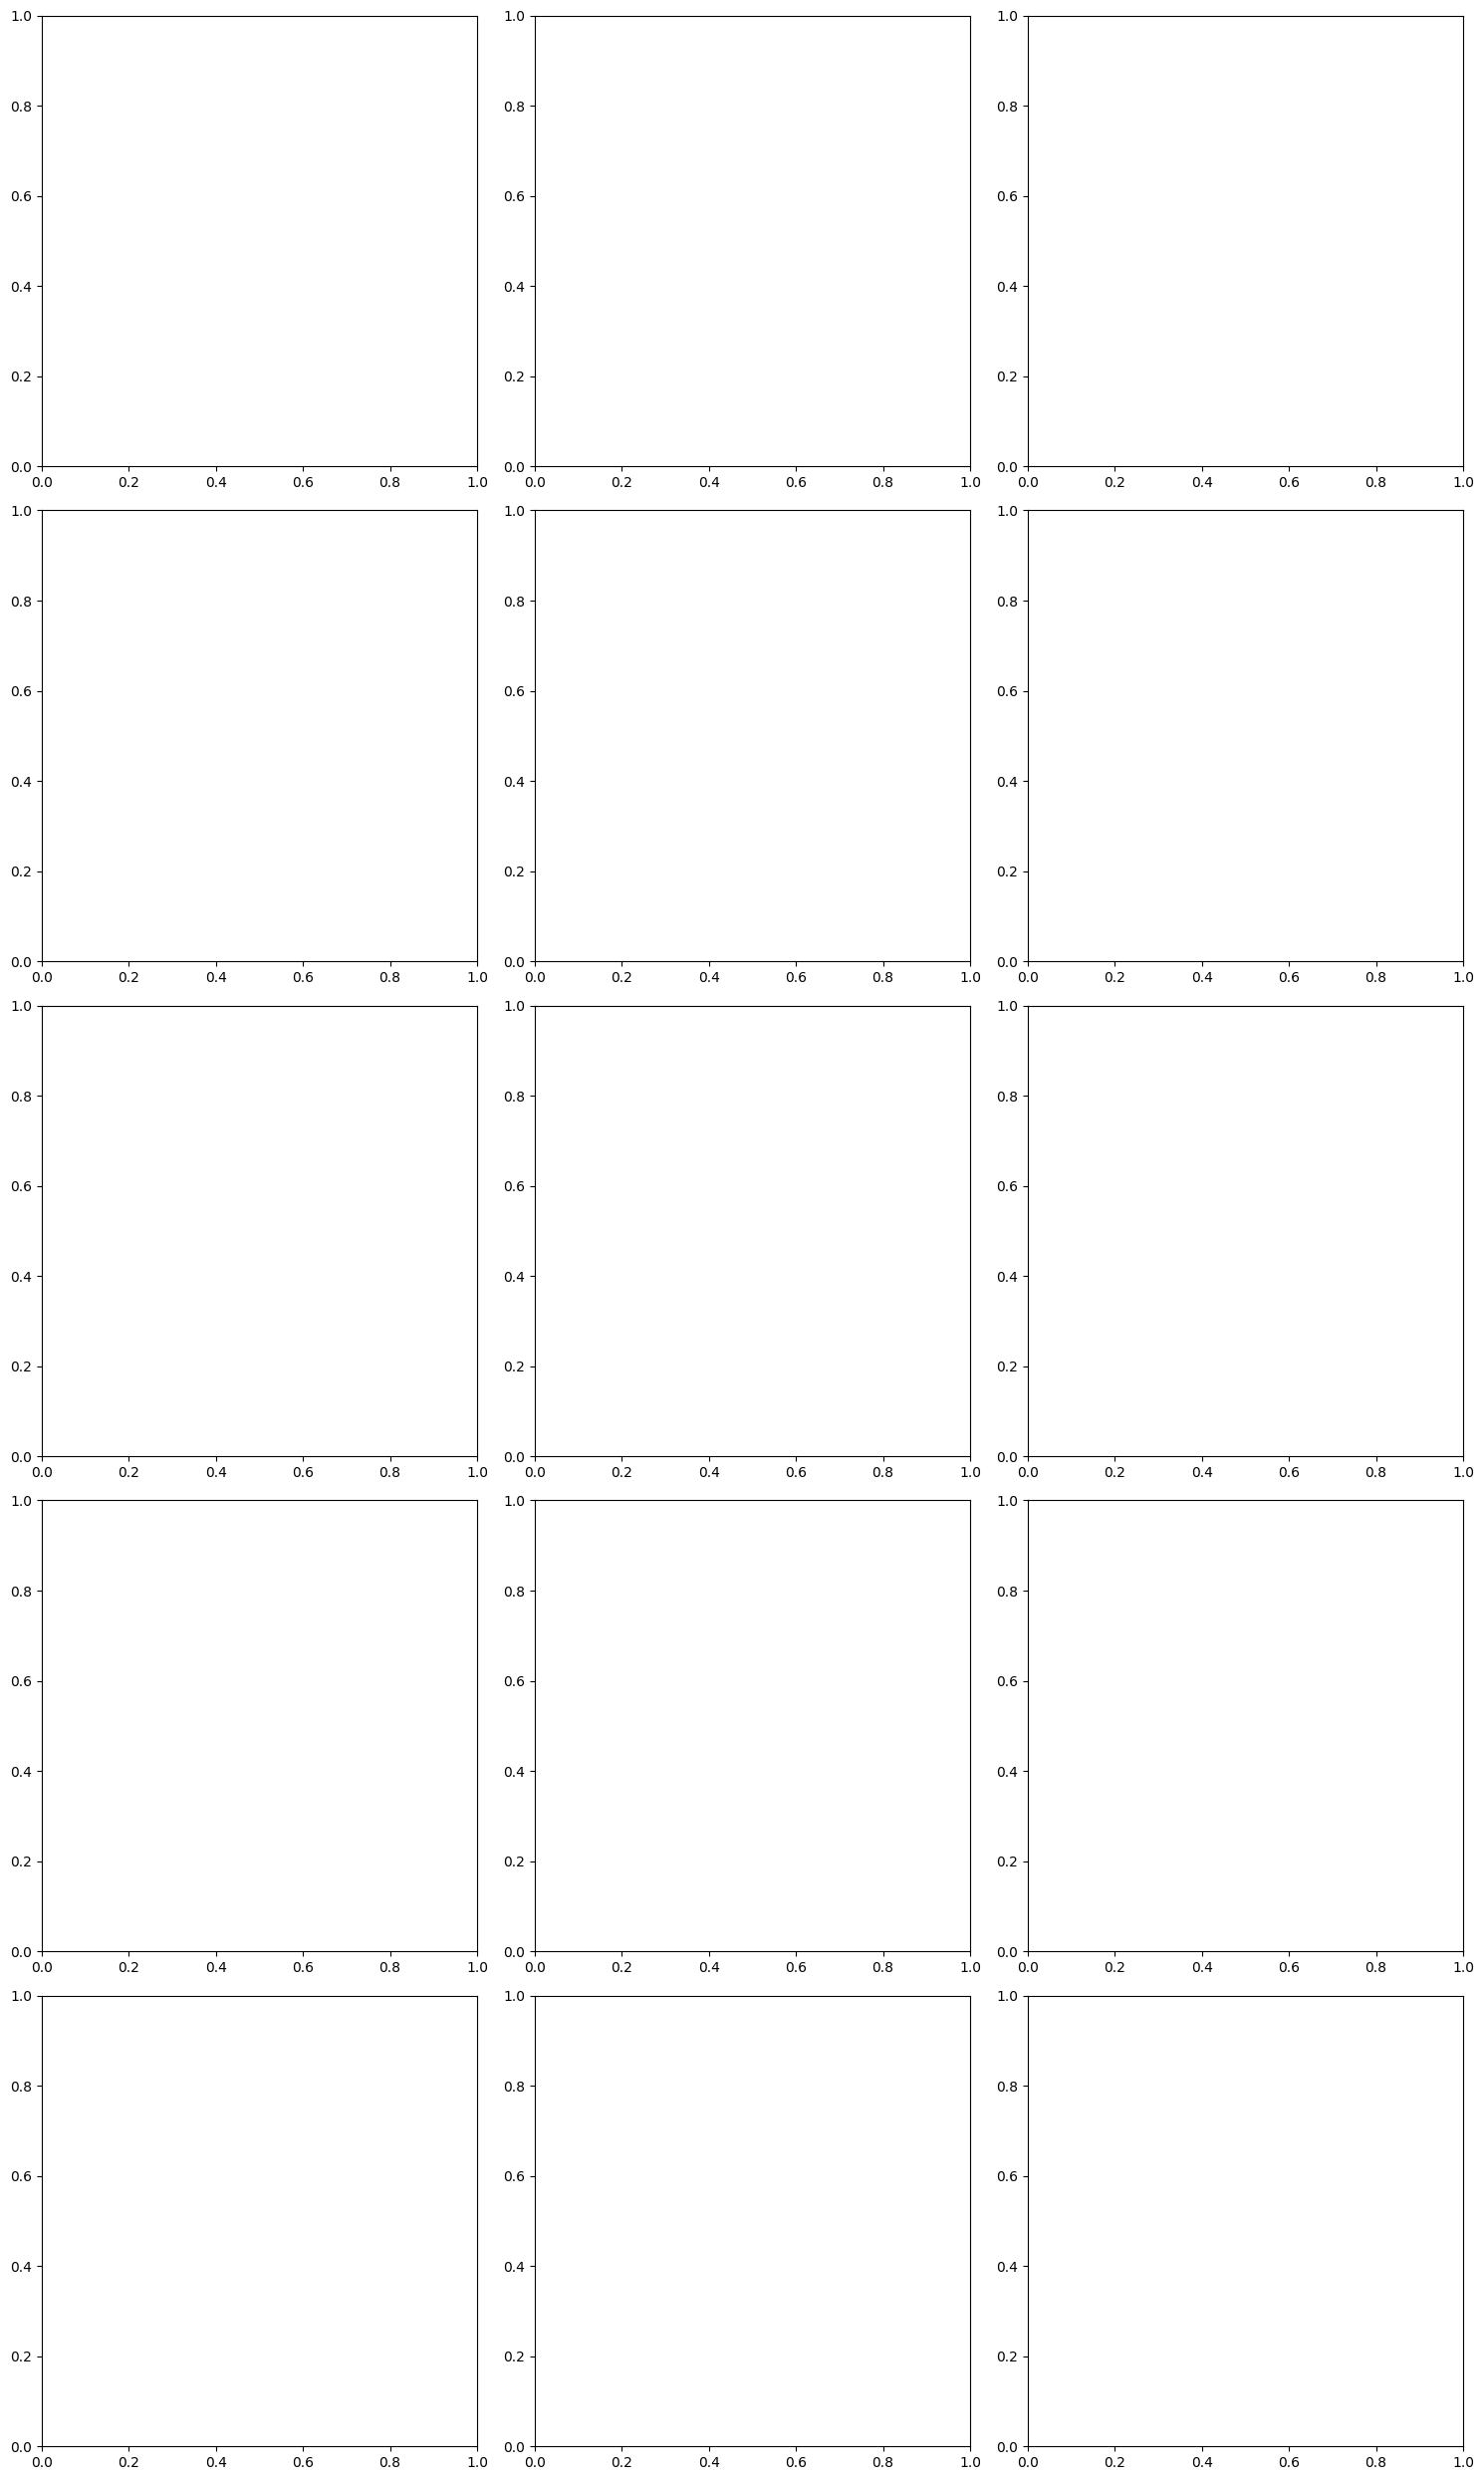

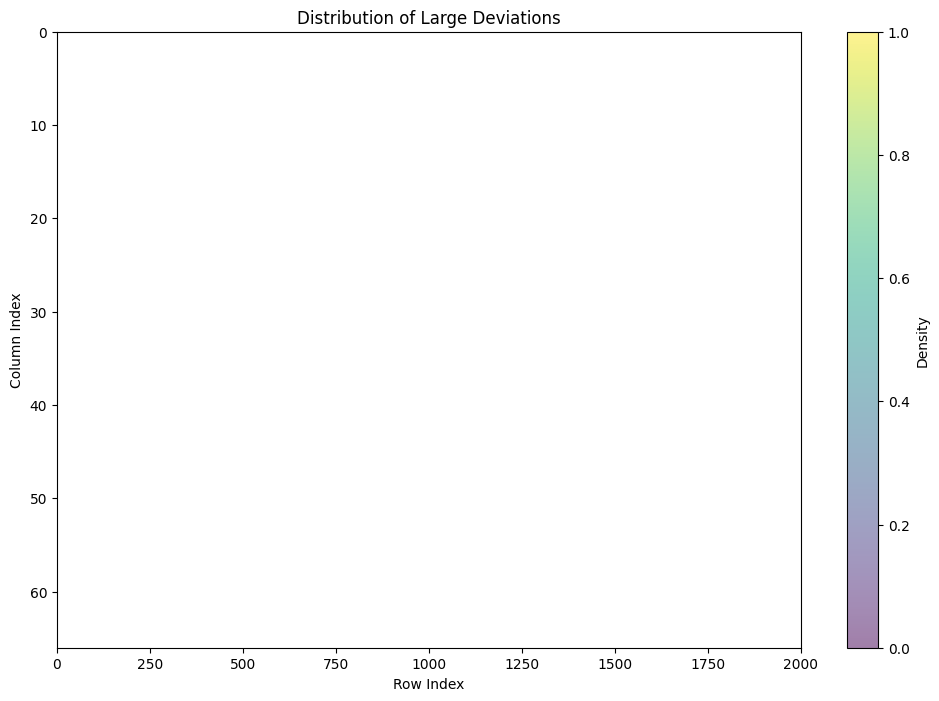

Number of elements with large deviations: 0
Percentage of elements with large deviations: 0.00%


In [56]:
# To debug differences, check for deviations between benchmark (numpy) and new (tensor) partial responses
compare_and_visualize(pr_train_leb_2k, pr_train_benchmark_leb_2k)

Something is going wrong with the 2nd batch calculations. check method. Confirm as well with previous implementation that a similar but more mild pattern isn't observed.

In [59]:
%reload_ext autoreload
test_refactored_partial_responses(partial_responses,tensor_input=True,filename=MODELS_DIR.joinpath("pr_cpu_lebesgue_20240816_170150.pkl"),batch_size=500)

Unvariate 0 on cpu
Unvariate 1 on cpu
Unvariate 2 on cpu
Unvariate 3 on cpu
Unvariate 4 on cpu
Unvariate 5 on cpu
Unvariate 6 on cpu
Unvariate 7 on cpu
Unvariate 8 on cpu
Unvariate 9 on cpu
Unvariate 10 on cpu
Bivariate 0,1 on cpu
Bivariate 0,2 on cpu
Bivariate 0,3 on cpu
Bivariate 0,4 on cpu
Bivariate 0,5 on cpu
Bivariate 0,6 on cpu
Bivariate 0,7 on cpu
Bivariate 0,8 on cpu
Bivariate 0,9 on cpu
Bivariate 0,10 on cpu
Bivariate 1,2 on cpu
Bivariate 1,3 on cpu
Bivariate 1,4 on cpu
Bivariate 1,5 on cpu
Bivariate 1,6 on cpu
Bivariate 1,7 on cpu
Bivariate 1,8 on cpu
Bivariate 1,9 on cpu
Bivariate 1,10 on cpu
Bivariate 2,3 on cpu
Bivariate 2,4 on cpu
Bivariate 2,5 on cpu
Bivariate 2,6 on cpu
Bivariate 2,7 on cpu
Bivariate 2,8 on cpu
Bivariate 2,9 on cpu
Bivariate 2,10 on cpu
Bivariate 3,4 on cpu
Bivariate 3,5 on cpu
Bivariate 3,6 on cpu
Bivariate 3,7 on cpu
Bivariate 3,8 on cpu
Bivariate 3,9 on cpu
Bivariate 3,10 on cpu
Bivariate 4,5 on cpu
Bivariate 4,6 on cpu
Bivariate 4,7 on cpu
Bivariate

False

# Test lebesgue GPU

In [22]:
print(torch.cuda.is_available())

True


In [23]:
# View new lebesgue results
%reload_ext autoreload

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp = mlp.to(device)

x_train_tensor = torch.tensor(x_train.values, dtype=torch.float32, device=device)
x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32,device=device)

pr_train_leb, pr_test_leb, bivariate_inputs_leb = partial_responses(x_train_tensor[:500,:],x_test_tensor[:500,:],mlp,method='lebesgue',device=device)

In [24]:
print(f"First few univariate responses (train): {pr_train_leb[:5, :5]}")
print(f"First few bivariate responses (train): {pr_train_leb[:5, 11:16]}")
print(f"First few univariate responses (test): {pr_test_leb[:5, :5]}")
print(f"First few bivariate responses (test): {pr_test_leb[:5, 11:16]}")

First few univariate responses (train): tensor([[ 0.0228, -0.1354, -0.0824,  0.0514, -0.0488],
        [-0.1893,  0.0641, -0.0497, -0.1613, -0.0488],
        [ 0.2478, -0.0740,  0.0725, -0.0465, -0.0488],
        [ 0.1899,  0.4599,  0.0573,  0.2237, -0.0488],
        [-0.1667, -0.2017,  0.0005, -0.2523, -0.0488]], device='cuda:0')
First few bivariate responses (train): tensor([[ 0.0098, -0.0015, -0.0078,  0.0016, -0.0016],
        [ 0.0045, -0.0035, -0.0181, -0.0017, -0.0062],
        [ 0.0097,  0.0145, -0.0056,  0.0005,  0.0098],
        [-0.0577,  0.0139, -0.0323,  0.0012,  0.0065],
        [-0.0162, -0.0050, -0.0325, -0.0010, -0.0069]], device='cuda:0')
First few univariate responses (test): tensor([[-0.5321, -0.3919, -0.4584, -0.4138, -0.4498],
        [-0.5453, -0.4386, -0.4736, -0.3323, -0.4498],
        [-0.5446, -0.3714, -0.4067, -0.4793, -0.4498],
        [-0.5417, -0.4862, -0.2747, -0.5234, -0.4498],
        [-0.1191, -0.4170, -0.3111,  0.0644, -0.4498]], device='cuda:0')
Fir

In [25]:
print(f"First few univariate responses (train): {pr_train_benchmark_leb[:5, :5]}")
print(f"First few bivariate responses (train): {pr_train_benchmark_leb[:5, 11:16]}")
print(f"First few univariate responses (test): {pr_test_benchmark_leb[:5, :5]}")
print(f"First few bivariate responses (test): {pr_test_benchmark_leb[:5, 11:16]}")

First few univariate responses (train): [[ 0.02279246 -0.13538277 -0.08238709  0.05137408 -0.04876649]
 [-0.18926609  0.06411755 -0.04966962 -0.16132271 -0.04876649]
 [ 0.24780893 -0.07403123  0.07245362 -0.04652226 -0.04876649]
 [ 0.1899035   0.45994484  0.0572989   0.2237339  -0.04876649]
 [-0.1667074  -0.20167506  0.00046611 -0.25231373 -0.04876649]]
First few bivariate responses (train): [[ 0.00975614 -0.0014504  -0.00784853  0.0015941  -0.00162662]
 [ 0.00449143 -0.00350396 -0.01813054 -0.00167009 -0.00617562]
 [ 0.00969791  0.01454909 -0.00556087  0.0005069   0.00979852]
 [-0.05770344  0.01386476 -0.0322869   0.00121743  0.00653278]
 [-0.0161572  -0.00503564 -0.03246517 -0.00096593 -0.00687471]]
First few univariate responses (test): [[-0.53211224 -0.39187014 -0.45838583 -0.41380584 -0.44975626]
 [-0.54525983 -0.43861377 -0.47356451 -0.33227766 -0.44975626]
 [-0.54459131 -0.37141097 -0.40668476 -0.47929466 -0.44975626]
 [-0.54169858 -0.48624599 -0.27472937 -0.52340114 -0.44975626

## Test Lebesgue GPU full dataset (batching)

In [26]:
import torch

print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"GPU memory cached: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

GPU available: True
GPU memory allocated: 0.01 GB
GPU memory cached: 0.05 GB


In [27]:
# View new lebesgue results
%reload_ext autoreload

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp = mlp.to(device)

x_train_tensor = torch.tensor(x_train.values, dtype=torch.float32, device=device)
x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32,device=device)

pr_train_leb_full, pr_test_leb_full, bivariate_inputs_leb_full = partial_responses(x_train_tensor,x_test_tensor,mlp,method='lebesgue',device=device)

In [29]:
pr_train_leb_full.shape

torch.Size([31315, 66])

In [30]:
print(f"First few univariate responses (train): {pr_train_leb_full[:5, :5]}")
print(f"First few bivariate responses (train): {pr_train_leb_full[:5, 11:16]}")
print(f"First few univariate responses (test): {pr_test_leb_full[:5, :5]}")
print(f"First few bivariate responses (test): {pr_test_leb_full[:5, 11:16]}")

First few univariate responses (train): tensor([[ 0.0137, -0.1264, -0.0871,  0.0716, -0.0474],
        [-0.1790,  0.0454, -0.0552, -0.1678, -0.0474],
        [ 0.2427, -0.0768,  0.0676, -0.0361, -0.0474],
        [ 0.1822,  0.4337,  0.0522,  0.2546, -0.0474],
        [-0.1620, -0.1692, -0.0053, -0.2804, -0.0474]], device='cuda:0')
First few bivariate responses (train): tensor([[ 0.0114, -0.0006, -0.0085,  0.0014, -0.0017],
        [ 0.0074, -0.0019, -0.0155, -0.0013, -0.0037],
        [ 0.0107,  0.0210, -0.0091,  0.0003,  0.0049],
        [-0.0525,  0.0187, -0.0330,  0.0011,  0.0030],
        [-0.0157, -0.0054, -0.0326, -0.0008, -0.0043]], device='cuda:0')
First few univariate responses (test): tensor([[-0.4581, -0.3130, -0.3826, -0.3431, -0.3830],
        [-0.4712, -0.3577, -0.3691, -0.2595, -0.3830],
        [-0.4707, -0.2934, -0.3337, -0.4108, -0.3830],
        [-0.4678, -0.4023, -0.2068, -0.4568, -0.3830],
        [-0.0405, -0.3371, -0.2419,  0.1371, -0.3830]], device='cuda:0')
Fir

In [66]:
# Saving
filename_pr_leb_full = MODELS_DIR.joinpath('partial_responses_data_leb_all.pkl')

save_partial_responses_results(x_train_tensor, x_test_tensor, mlp, pr_train_leb_full, pr_test_leb_full, bivariate_inputs_leb_full, 'lebesgue', device, filename=filename_pr_leb_full)

Results and arguments saved to C:\Users\localuser\PRiSM\prism_github\models\partial_responses_data_leb_all.pkl


## Lebesgue results nomogram

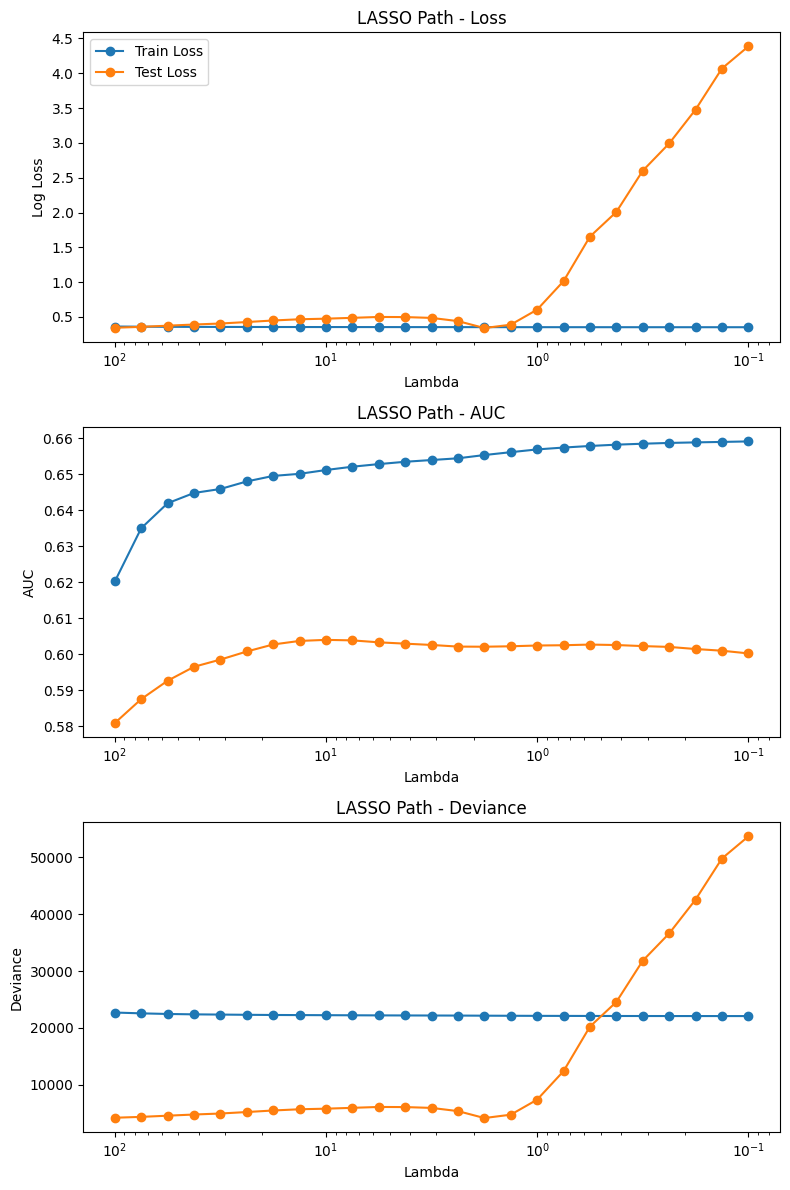

In [37]:
lasso_leb_full = lasso_results = lasso(
    pr_train_leb_full, 
    pr_test_leb_full, 
    y_train, 
    y_test, 
    bivariate_inputs_leb_full,
    feature_names=feature_names,
    nlambda=25, 
    min_lambda=0.1,
    max_lambda=100,
    tol=1e-4,
    batch_size=2
)

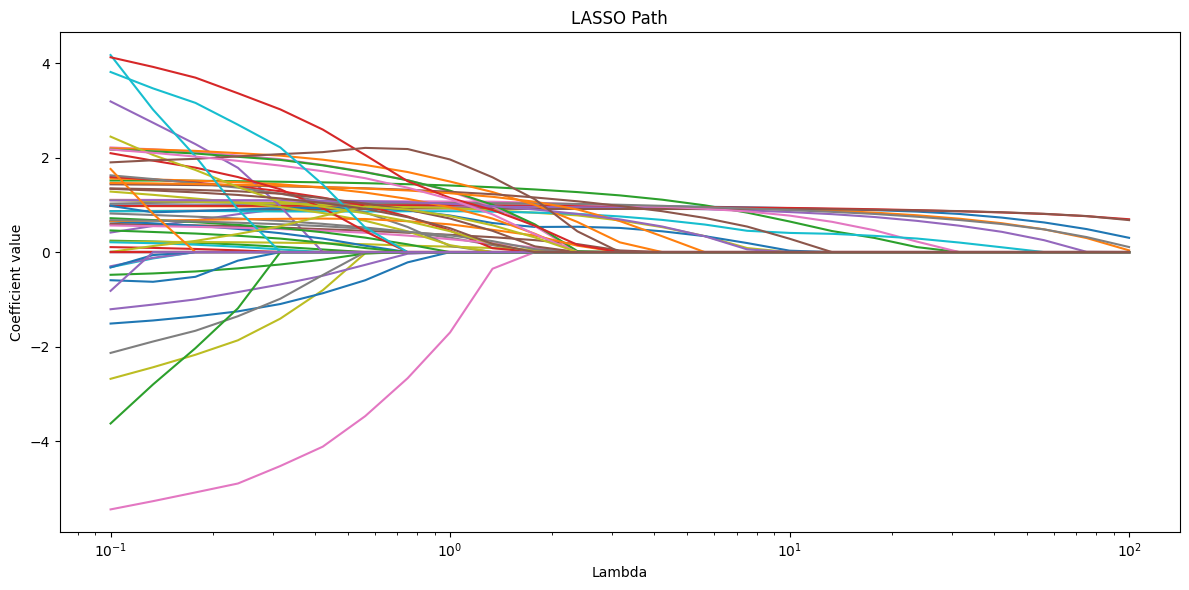

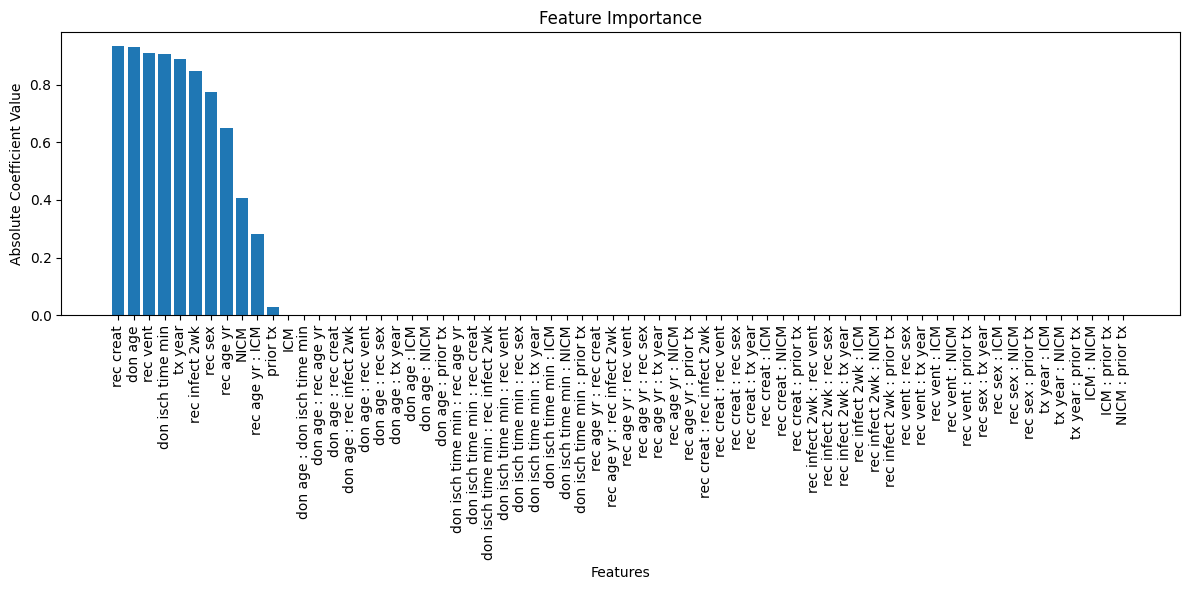

In [40]:
lasso_leb_full.select_lambda(8)
lasso_leb_full.plot_lambda_path()
lasso_leb_full.plot_feature_importance()